In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/netflix_titles.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.head(3)

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [3]:
# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Clean duration
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)

print(f"✅ Cleaned! Shape: {df.shape}")
print(f"Missing values remaining:\n{df.isnull().sum()}")

✅ Cleaned! Shape: (8807, 15)
Missing values remaining:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
duration_int     3
dtype: int64


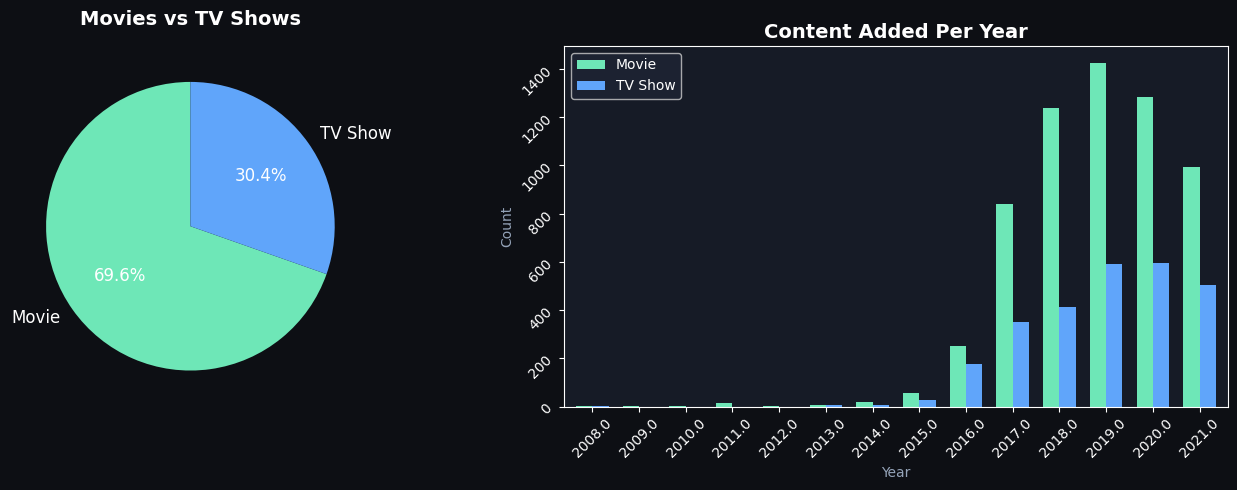

✅ Chart saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D0F14')

# Pie chart
colors = ['#6EE7B7', '#60A5FA']
type_counts = df['type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            textprops={'color': 'white', 'fontsize': 12})
axes[0].set_facecolor('#161B26')
axes[0].set_title('Movies vs TV Shows', color='white', fontsize=14, fontweight='bold', pad=15)

# Bar chart - content added per year
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly.plot(kind='bar', ax=axes[1], color=['#6EE7B7', '#60A5FA'], width=0.7)
axes[1].set_facecolor('#161B26')
axes[1].set_title('Content Added Per Year', color='white', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', color='#94A3B8')
axes[1].set_ylabel('Count', color='#94A3B8')
axes[1].tick_params(colors='white', rotation=45)
axes[1].legend(facecolor='#1E2535', labelcolor='white')

plt.tight_layout()
plt.savefig('../src/content_type_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0D0F14')
plt.show()
print("✅ Chart saved!")

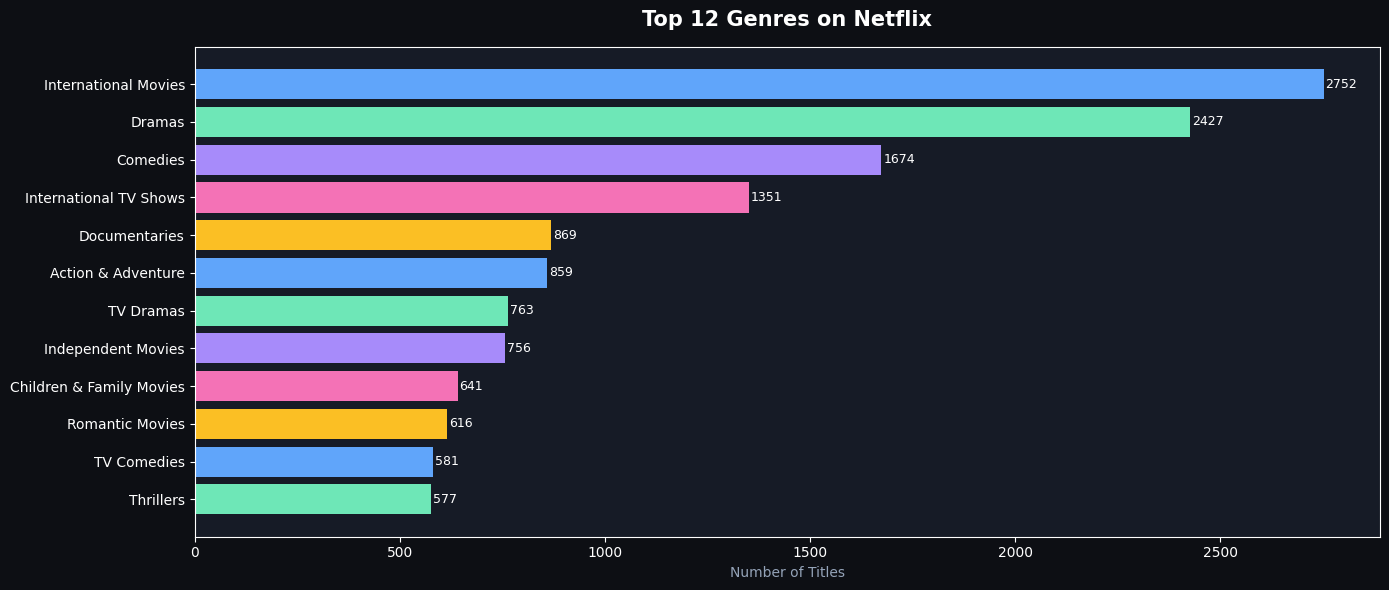

✅ Chart saved!


In [5]:
# Explode genres
df['listed_in_split'] = df['listed_in'].str.split(', ')
genres_df = df.explode('listed_in_split')
top_genres = genres_df['listed_in_split'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D0F14')
ax.set_facecolor('#161B26')

bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=['#6EE7B7','#60A5FA','#FBBF24','#F472B6','#A78BFA',
                      '#6EE7B7','#60A5FA','#FBBF24','#F472B6','#A78BFA','#6EE7B7','#60A5FA'])
ax.set_title('Top 12 Genres on Netflix', color='white', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', color='#94A3B8')
ax.tick_params(colors='white')
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('../src/genre_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0D0F14')
plt.show()
print("✅ Chart saved!")

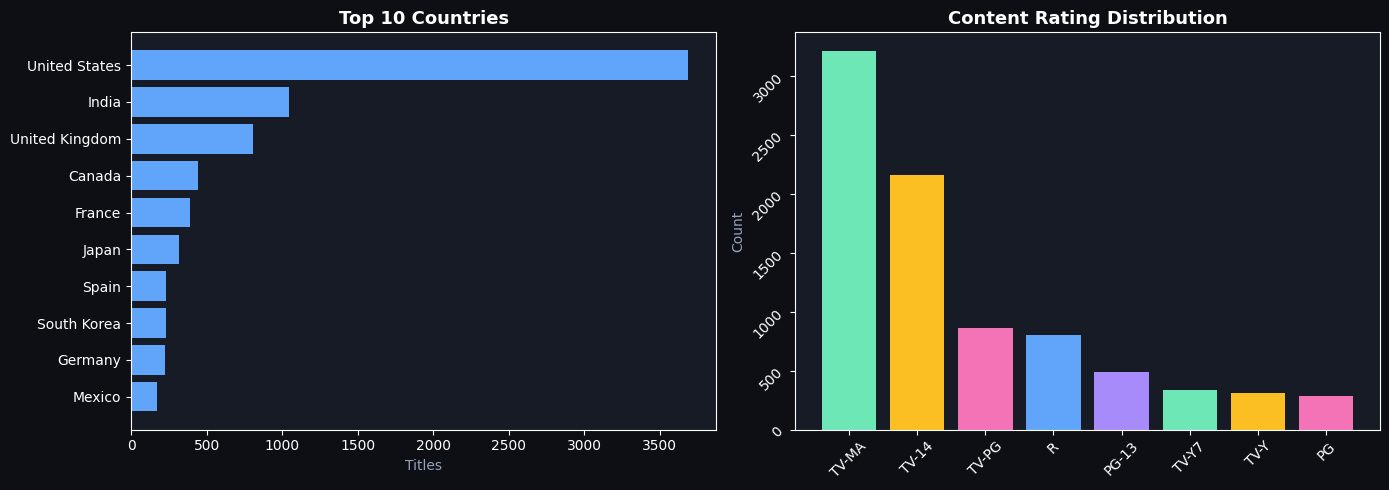

✅ Chart saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D0F14')

# Top countries
top_countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode().value_counts().head(10)
axes[0].set_facecolor('#161B26')
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color='#60A5FA')
axes[0].set_title('Top 10 Countries', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].set_xlabel('Titles', color='#94A3B8')

# Rating distribution
top_ratings = df['rating'].value_counts().head(8)
axes[1].set_facecolor('#161B26')
axes[1].bar(top_ratings.index, top_ratings.values,
            color=['#6EE7B7','#FBBF24','#F472B6','#60A5FA','#A78BFA','#6EE7B7','#FBBF24','#F472B6'])
axes[1].set_title('Content Rating Distribution', color='white', fontsize=13, fontweight='bold')
axes[1].tick_params(colors='white', rotation=45)
axes[1].set_ylabel('Count', color='#94A3B8')

plt.tight_layout()
plt.savefig('../src/country_rating_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0D0F14')
plt.show()
print("✅ Chart saved!")

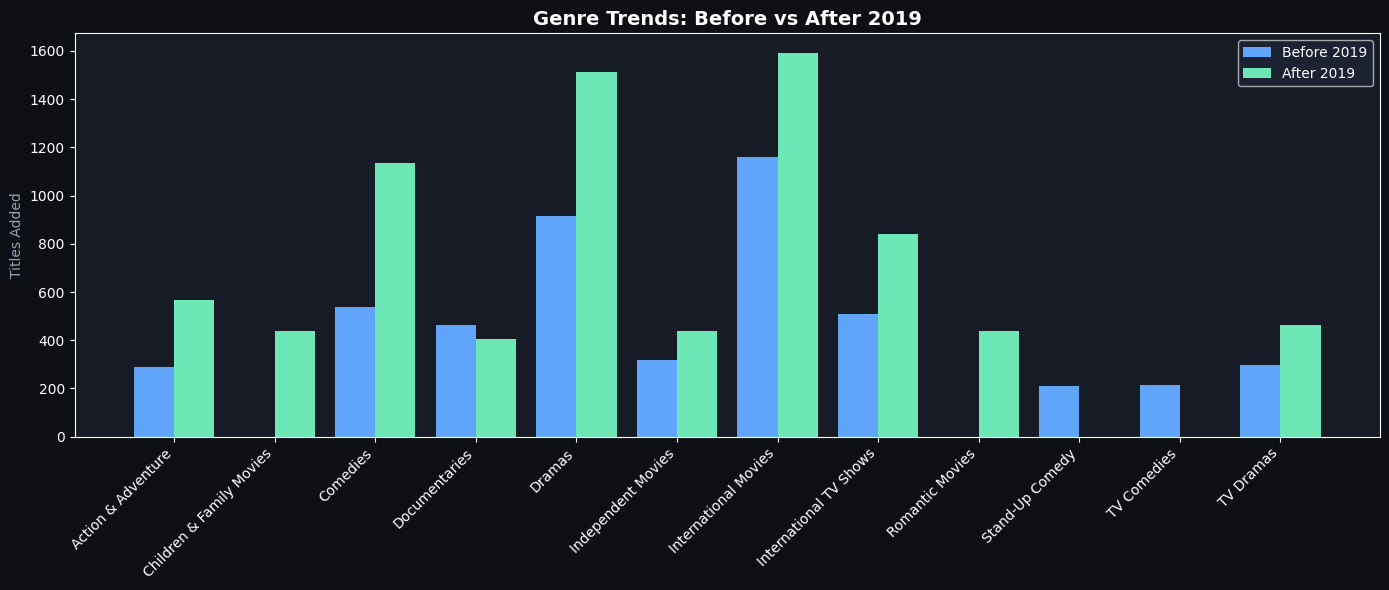

✅ Chart saved!


In [7]:
# Genre trends post 2020 — Recruiter tip wala insight!
recent = df[df['year_added'] >= 2019].copy()
old = df[df['year_added'] < 2019].copy()

recent_genres = recent.explode('listed_in_split')['listed_in_split'].value_counts().head(10)
old_genres = old.explode('listed_in_split')['listed_in_split'].value_counts().head(10)

# Find genres that grew
genre_growth = pd.DataFrame({
    'Before 2019': old_genres,
    'After 2019': recent_genres
}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D0F14')
ax.set_facecolor('#161B26')

x = range(len(genre_growth))
ax.bar([i - 0.2 for i in x], genre_growth['Before 2019'], width=0.4,
       label='Before 2019', color='#60A5FA')
ax.bar([i + 0.2 for i in x], genre_growth['After 2019'], width=0.4,
       label='After 2019', color='#6EE7B7')
ax.set_xticks(x)
ax.set_xticklabels(genre_growth.index, rotation=45, ha='right', color='white')
ax.set_title('Genre Trends: Before vs After 2019', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.set_ylabel('Titles Added', color='#94A3B8')
ax.legend(facecolor='#1E2535', labelcolor='white')

plt.tight_layout()
plt.savefig('../src/genre_trends.png', dpi=150, bbox_inches='tight', facecolor='#0D0F14')
plt.show()
print("✅ Chart saved!")

In [8]:
df.to_csv('../data/netflix_cleaned.csv', index=False)
print("✅ Cleaned data saved!")
print(f"\n📊 Final Dataset Shape: {df.shape}")
print(f"🎬 Total Movies: {len(df[df['type']=='Movie'])}")
print(f"📺 Total TV Shows: {len(df[df['type']=='TV Show'])}")
print(f"🌍 Unique Countries: {df['country'].nunique()}")
print(f"🎭 Unique Genres: {genres_df['listed_in_split'].nunique()}")
print(f"📅 Year Range: {int(df['release_year'].min())} - {int(df['release_year'].max())}")

✅ Cleaned data saved!

📊 Final Dataset Shape: (8807, 16)
🎬 Total Movies: 6131
📺 Total TV Shows: 2676
🌍 Unique Countries: 749
🎭 Unique Genres: 42
📅 Year Range: 1925 - 2021


In [9]:
import pandas as pd
df = pd.read_csv('../data/netflix_cleaned.csv')
df['year_added'] = df['year_added'].astype(str)
df.to_csv('../data/netflix_cleaned.csv', index=False)
print("Done!")

Done!
